To use this notebook, all you need to do is input your high and low resolution file paths as hr and lr. \ Then, the notebook will do the rest of the work for you– calculating radial profiles, finding densities, and the abel transform.

Note that the proper motion function in header_setup uses the proper motion of Betelgeuse. Change as needed.

In [1]:
from matplotlib import pyplot as plt
import numpy as np

from astropy.io import fits
from astropy import units as u

In [2]:
from everything import full_analysis

Match function imported.
running
Ready to go!


In [3]:
from radial import radial_read
from dens import density_model

In [4]:
from everything import plot_2d

Input your high and low resolution files

In [5]:
cd

/Users/iman


In [6]:
hr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_TE_cont_R0.image.image.tt0.fits'
lr = 'Documents/cuny_ms/jan29_data/from_server/Betelgeuse_all_cont_1-1.image.image.tt0.fits'
data3, data_1d3, radius3, data_dens_1d3, data_dens_2d3, data_plot3, info3 = full_analysis(hr,lr)
# this should be lr
info3['lr']['kspatres']
# this should be hr


False
First epoch shifted to second.
Header information imported.
Header information imported.


indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in parameterized keywords must not have leading zeroes. [astropy.wcs.wcs]
indices in param

Alignment and subtraction complete. Info dictionaries imported.


/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/iman/anaconda3/lib/python3.11/site-packages/astropy/units/quantity.py:666: RuntimeWarning: divide by zero encountered in power
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/iman/anaconda3/lib/python3.11/site-packages/numpy

0.040566339161841755

In [7]:
from everything import plot_1d, plot_1d_err,plot_1d_skip

/Users/iman/Documents/cuny_ms/csm_pipeline/everything.py:284: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


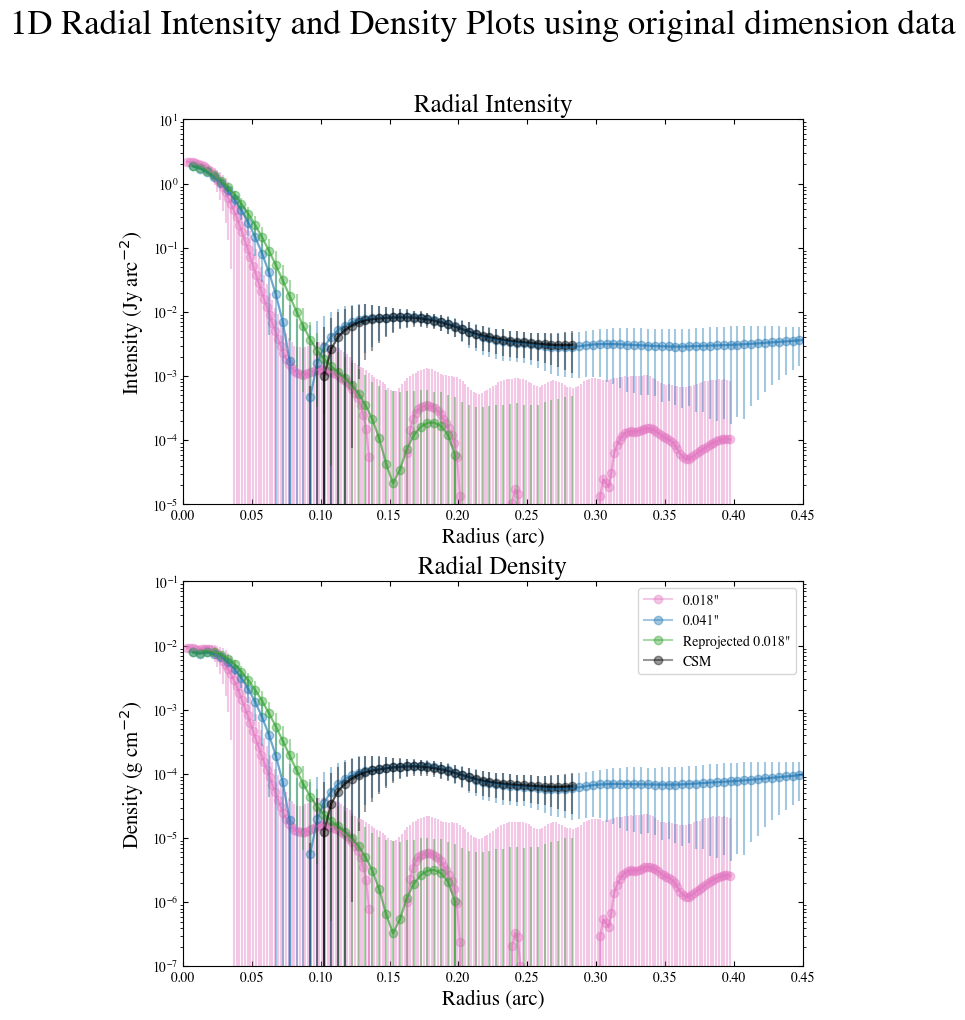

In [8]:
plot_1d(data_1d3, data_dens_1d3,info3,radius3,ax1_ymin=1e-5,ax1_ymax=1e1,ax2_ymin=1e-7,ax2_ymax=1e-1)#,xmax=0.35)
#plot_1d(data_1d3, data_dens_1d3,info3,radius3,ax1_ymin=-1e-1,ax1_ymax=6e5,ax2_ymin=1e0,ax2_ymax=1e1)#,xmax=0.35)

/Users/iman/Documents/cuny_ms/csm_pipeline/everything.py:349: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


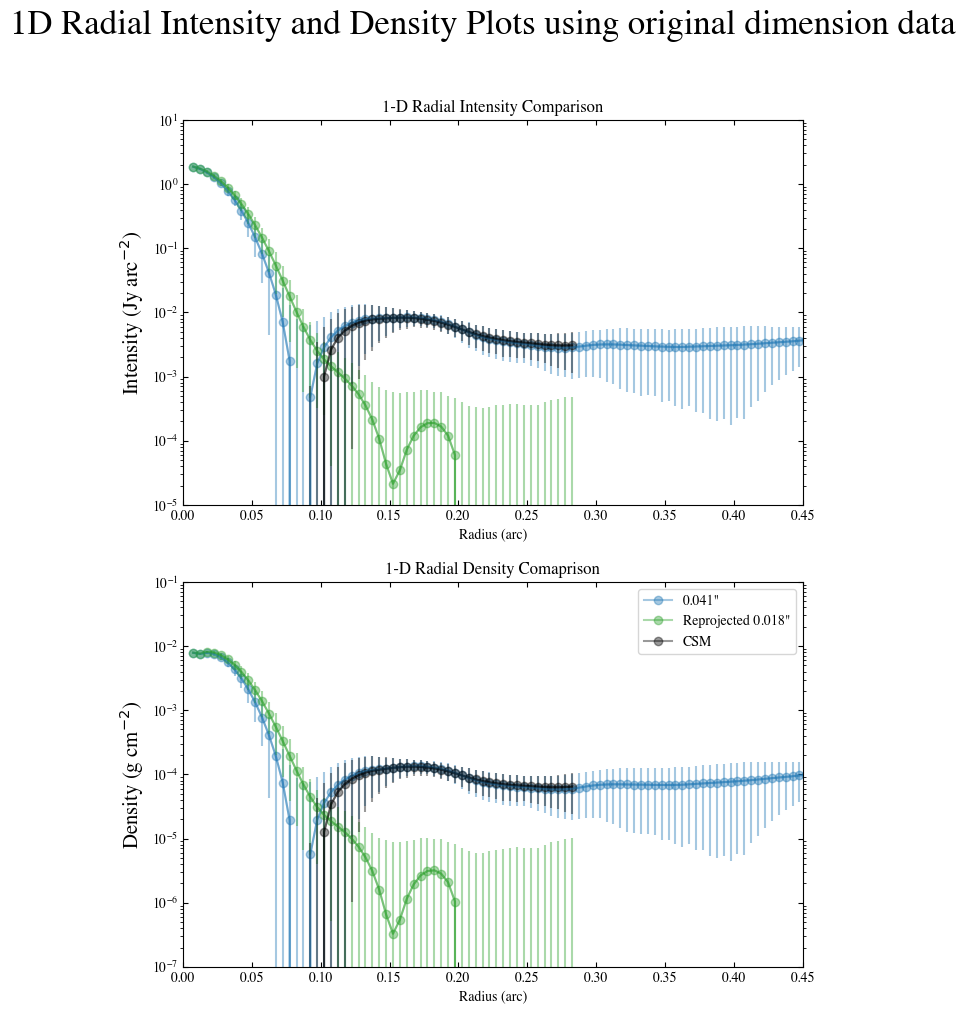

In [9]:
plot_1d_skip(data_1d3, data_dens_1d3,info3,radius3,ax1_ymin=1e-5,ax1_ymax=1e1,ax2_ymin=1e-7,ax2_ymax=1e-1)#,xmax=0.35)

/Users/iman/Documents/cuny_ms/csm_pipeline/everything.py:221: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


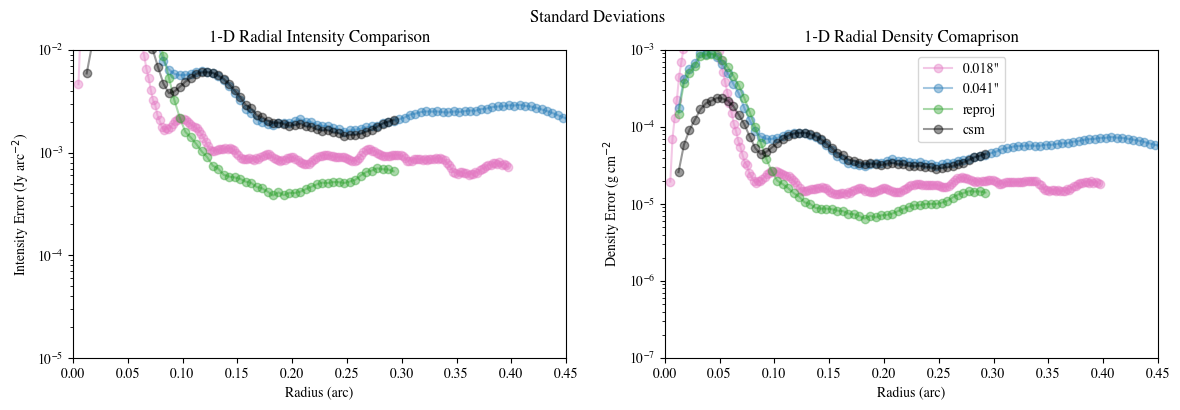

In [10]:
plot_1d_err(info3,radius3,ax1_ymin=1e-5,ax1_ymax=1e-2,ax2_ymin=1e-7,ax2_ymax=1e-3)#,xmax=0.35)


In [11]:
from dens import kappa
from astropy.modeling.models import BlackBody


In [12]:
def max_test(data_1d):
    title = ['hr','lr','reproj','csm']
    lmda_AA = 8.87e6*u.AA
    
    B = BlackBody(temperature = 3000*u.K)
    B=B(lmda_AA)
    arcsec2_per_sr=4.25e10*u.arcsec**2/u.sr
    ergcmshz_per_jy = 1.0e-23*u.erg/u.cm**2/u.s/u.Hz/u.Jy
    k = kappa(887.0*u.um)

    B_jy_arcsec2 = B/arcsec2_per_sr/ergcmshz_per_jy

    sigma={}

    for i in title:
        sigma[i]= np.nanmax(np.nanmax(data_1d[i]))/ (k*B_jy_arcsec2)

    return sigma


In [13]:
max_test(data_1d3)

{'hr': <Quantity 0.01111003 g / cm2>,
 'lr': <Quantity 0.00941045 g / cm2>,
 'reproj': <Quantity 0.0094502 g / cm2>,
 'csm': <Quantity 4.17848432e-05 g / cm2>}

In [14]:
print("hr: ",np.nanmax(data_dens_1d3['hr']))
print("lr: ",np.nanmax(data_dens_1d3['lr']))
print("reproj: ",np.nanmax(data_dens_1d3['reproj']))
print("csm: ",np.nanmax(data_dens_1d3['csm']))

hr:  0.009254187779894767 g / cm2
lr:  0.00786872949798627 g / cm2
reproj:  0.008077289985025526 g / cm2
csm:  0.0001319119209338921 g / cm2


csm, lr and reproj all get mapped to the same thing

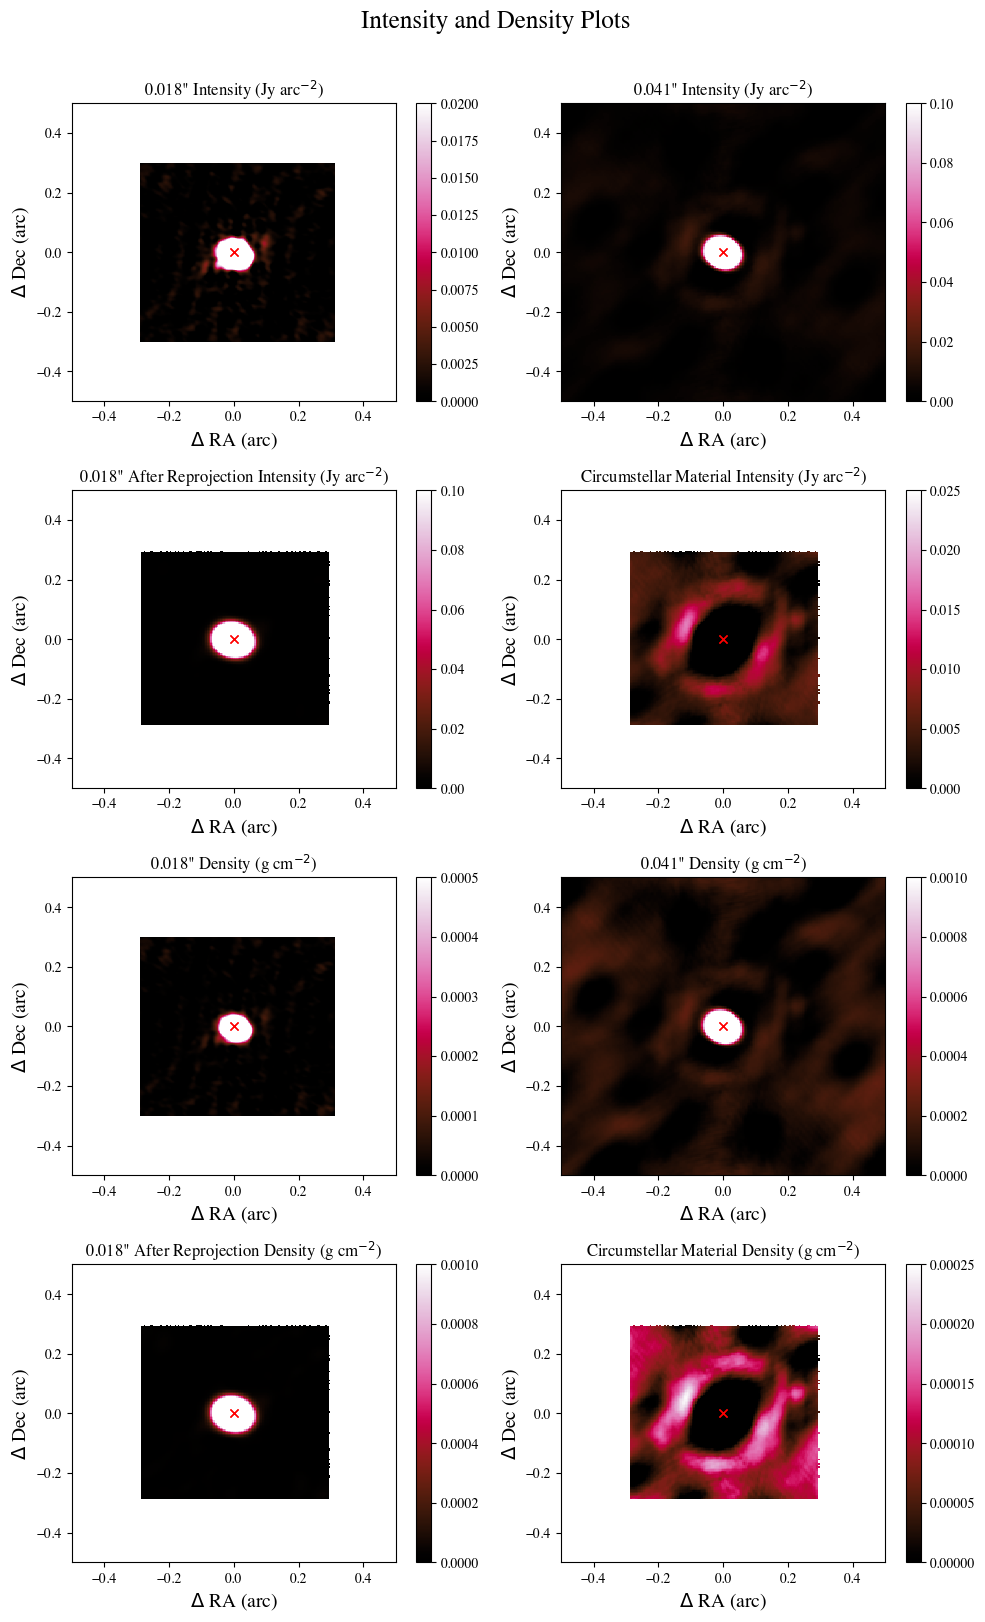

In [15]:
vminmax = [[0,.02], [0,.1],[0,.1],[0,0.025],
           [0,0.0005], [0,0.001],[0,0.001],[0,0.00025]]
plot_2d(data_plot3, info3, vminmax,minn=-.5)

## Abel transform

In [16]:
from abel import all_abel, do_abel, plot_1d_abel

In [17]:
data_dens_1d3

{'hr': <Quantity [ 9.25418778e-03,  9.16904814e-03,  9.03450998e-03,
             8.84378724e-03,  8.58934511e-03,  8.77279199e-03,
             8.97009110e-03,  8.97671071e-03,  8.79727756e-03,
             8.44428433e-03,  7.93926062e-03,  7.31149235e-03,
             6.59609520e-03,  5.82918759e-03,  5.04728193e-03,
             4.28226650e-03,  3.56098632e-03,  2.90418638e-03,
             2.32440411e-03,  1.82862615e-03,  1.41617451e-03,
             1.08234711e-03,  8.18909113e-04,  6.15505556e-04,
             4.61690428e-04,  3.46806991e-04,  2.61761987e-04,
             1.98745760e-04,  1.51648038e-04,  1.16048699e-04,
             8.87832039e-05,  6.78253658e-05,  5.17699595e-05,
             3.96516576e-05,  3.07184616e-05,  2.43112307e-05,
             1.98581294e-05,  1.68388889e-05,  1.48353503e-05,
             1.35334671e-05,  1.27320749e-05,  1.23289032e-05,
             1.22753188e-05,  1.25448166e-05,  1.30842181e-05,
             1.38005663e-05,  1.45652910e-05,  1.

In [18]:
d = {'hr': data_dens_1d3['hr'], 'lr': data_dens_1d3['lr'], 'reproj': data_dens_1d3['reproj'],"csm": data_dens_1d3['csm']}

In [19]:
abels = all_abel(d,radius3)

TypeError: all_abel() missing 1 required positional argument: 'info'

/Users/iman/Documents/almanalysis/streamlined/abel.py:85: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


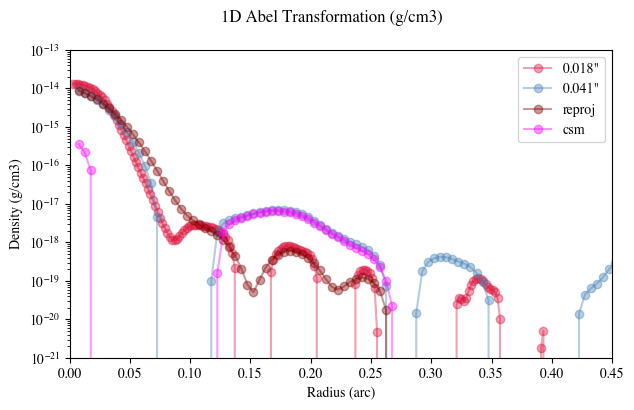

In [ ]:
plot_1d_abel(abels,info3,radius3,ax_ymin=1e-21,ax_ymax=1e-13)